# 01 — Agrupamento por Similaridade Visual (Pseudo-Pacientes)
## Prevenção de Vazamento de Dados (Data Leakage)

**Objetivo:**
Como não temos metadados de identificação do paciente/exame, dividimos as imagens por *similaridade visual* para evitar vazamento entre treino, validação e teste.
Este notebook extrai embeddings visuais com ResNet-50, calcula a similaridade cosseno entre todas as imagens, e agrupa imagens quase-idênticas (cosseno > 0.95) usando Componentes Conexos.

**Artefatos Gerados:**
- `project/splits/image_group_mapping.csv` (Mapeamento de `image_name` para `group_id`)
- `project/results/01_similarity_stats.json` (Estatísticas consolidadas)
- `project/figs/` (Gráficos em PT e EN)

**Nota Colab:** Para rodar no Google Colab com GPU, altere a variável `RUNNING_IN_COLAB = True`.

In [2]:
!nvidia-smi

Sat May 16 13:46:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   34C    P0            N/A  / 5001W |       0MiB /   3072MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# ==========================================
# CONFIGURAÇÕES E PATHS
# ==========================================
RUNNING_IN_COLAB = False  # Mude para True quando rodar no Colab

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/workspace') # Ajuste se necessário
else:
    ROOT = Path(r'/workspace')

DATA_DIR = ROOT / 'Dev' / 'Data'
IMGS_DIR = DATA_DIR / 'Imgs'
CSV_PATH = DATA_DIR / 'Imgs-anotadas' / 'dataset_labels.csv'

PROJECT_DIR = ROOT / 'project'
SPLITS_DIR = PROJECT_DIR / 'splits'
RESULTS_DIR = PROJECT_DIR / 'results'
FIGS_DIR = PROJECT_DIR / 'figs'

# Criar diretórios se não existirem
for d in [SPLITS_DIR, RESULTS_DIR, FIGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
SIMILARITY_THRESHOLD = 0.95

# Set seed for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 1. Carregamento do Dataset e Limpeza Básica

In [4]:
df_raw = pd.read_csv(CSV_PATH)
df_raw.rename(columns={"Coluna 1": "image_name"}, inplace=True)

# Remover valores nulos em image_name
df = df_raw.dropna(subset=['image_name']).copy()
df['image_name'] = df['image_name'].astype(str)

# Tratar as 12 duplicatas exatas de image_name (manter a primeira ocorrência)
df = df.drop_duplicates(subset=['image_name'], keep='first').reset_index(drop=True)

# Verificar se as imagens existem no disco
images_on_disk = set(f.name for f in IMGS_DIR.iterdir() if f.is_file())
df['exists'] = df['image_name'].apply(lambda x: x in images_on_disk)

print(f"Total de linhas originais: {len(df_raw)}")
print(f"Linhas após deduplicação: {len(df)}")
print(f"Imagens não encontradas no disco: {(~df['exists']).sum()}")

df = df[df['exists']].reset_index(drop=True)
print(f"Total de imagens válidas para análise: {len(df)}")

Total de linhas originais: 2500
Linhas após deduplicação: 2488
Imagens não encontradas no disco: 498
Total de imagens válidas para análise: 1990


## 2. Extração de Features (ResNet-50)

In [5]:
class FullImageDataset(Dataset):
    def __init__(self, img_names, img_dir, transform=None):
        self.img_names = img_names
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.img_names)
        
    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = FullImageDataset(df['image_name'].values, IMGS_DIR, transform)
num_workers = 2 if RUNNING_IN_COLAB else 0
loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=num_workers, pin_memory=True)

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)
model.fc = nn.Identity() # Remove a camada de classificação
model = model.to(device)
model.eval()

all_features = []
all_names = []

print("Extraindo embeddings visuais...")
with torch.no_grad():
    for images, names in tqdm(loader, desc="Extracting Features"):
        images = images.to(device)
        features = model(images)
        all_features.append(features.cpu().numpy())
        all_names.extend(names)

features_np = np.vstack(all_features)
print(f"Shape final das features: {features_np.shape}")

Extraindo embeddings visuais...


Extracting Features:   0%|          | 0/16 [00:00<?, ?it/s]

Shape final das features: (1990, 2048)


## 3. Matriz de Similaridade Cosseno

In [6]:
# Normalização L2 para cálculo otimizado via produto matricial
feat_norm = features_np / np.linalg.norm(features_np, axis=1, keepdims=True)

# Multiplicação de matrizes: O(N^2)
print("Calculando similaridade cosseno...")
similarity_matrix = np.dot(feat_norm, feat_norm.T)

# Zerar a diagonal para não encontrar a própria imagem como 'quase-duplicata'
np.fill_diagonal(similarity_matrix, 0.0)

# Maior similaridade para cada imagem
max_sims = np.max(similarity_matrix, axis=1)

print(f"Média das maiores similaridades: {np.mean(max_sims):.4f}")
print(f"Mediana das maiores similaridades: {np.median(max_sims):.4f}")

Calculando similaridade cosseno...
Média das maiores similaridades: 0.8429
Mediana das maiores similaridades: 0.8490


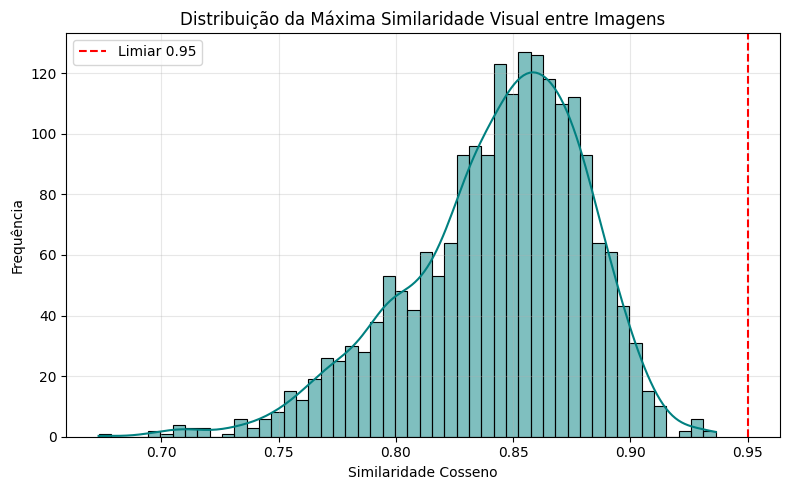

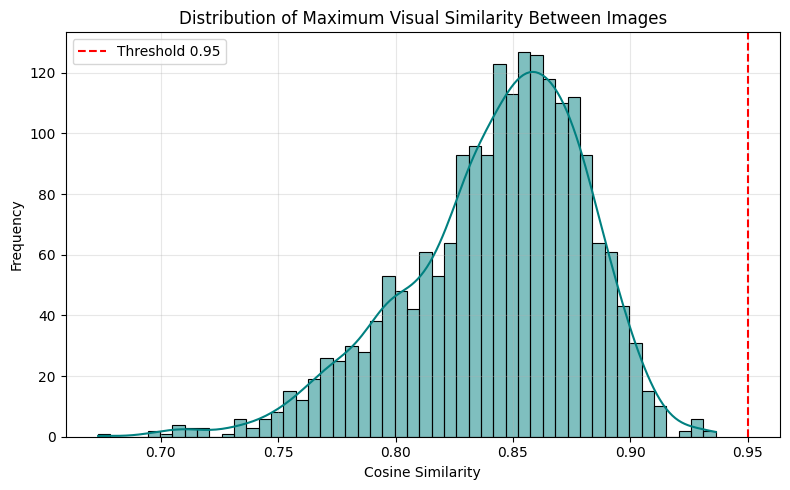

In [7]:
def plot_similarity_dist(max_sims, threshold, lang='PT'):
    plt.figure(figsize=(8, 5))
    sns.histplot(max_sims, bins=50, kde=True, color='teal')
    
    if lang == 'PT':
        plt.title('Distribuição da Máxima Similaridade Visual entre Imagens')
        plt.xlabel('Similaridade Cosseno')
        plt.ylabel('Frequência')
        label_thresh = f'Limiar {threshold}'
    else:
        plt.title('Distribution of Maximum Visual Similarity Between Images')
        plt.xlabel('Cosine Similarity')
        plt.ylabel('Frequency')
        label_thresh = f'Threshold {threshold}'
        
    plt.axvline(threshold, color='red', linestyle='--', label=label_thresh)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f"01_sim_max_distribution_{lang}.png", dpi=300)
    plt.show()

plot_similarity_dist(max_sims, SIMILARITY_THRESHOLD, 'PT')
plot_similarity_dist(max_sims, SIMILARITY_THRESHOLD, 'EN')

## 4. Agrupamento (Componentes Conexos)

In [8]:
# Criar matriz de adjacência baseada no limiar
A = similarity_matrix >= SIMILARITY_THRESHOLD

print(f"Encontrados {A.sum() // 2} pares de imagens com similaridade >= {SIMILARITY_THRESHOLD}")

# Construir grafo com NetworkX
G = nx.from_numpy_array(A)

# Extrair componentes conexos (grupos de imagens)
components = list(nx.connected_components(G))

# Mapeamento
image_to_group = {}
group_sizes = []

for group_id, comp in enumerate(components):
    group_sizes.append(len(comp))
    for idx in comp:
        image_to_group[all_names[idx]] = group_id

# Adicionar ao dataframe
df['group_id'] = df['image_name'].map(image_to_group)

print(f"Total de pseudo-pacientes (grupos únicos): {df['group_id'].nunique()}")
print(f"Tamanho máximo de um grupo: {max(group_sizes)}")

Encontrados 0 pares de imagens com similaridade >= 0.95
Total de pseudo-pacientes (grupos únicos): 1990
Tamanho máximo de um grupo: 1


In [9]:
# Tabela de Tamanho dos Grupos
group_counts = df['group_id'].value_counts()
size_counts = group_counts.value_counts().sort_index()

print("Distribuição do tamanho dos grupos:")
display(pd.DataFrame({'Tamanho do Grupo (Imagens)': size_counts.index, 'Quantidade de Grupos': size_counts.values}))

Distribuição do tamanho dos grupos:


,Tamanho do Grupo (Imagens),Quantidade de Grupos
0,1,1990


## 5. Salvar Artefatos e Resultados

In [10]:
# Salvar o mapeamento
mapping_csv = SPLITS_DIR / "image_group_mapping.csv"
df[['image_name', 'group_id']].to_csv(mapping_csv, index=False)
print(f"Mapeamento salvo em: {mapping_csv}")

# Consolidar estatísticas
stats = {
    "total_images": len(df),
    "total_groups": int(df['group_id'].nunique()),
    "similarity_threshold": SIMILARITY_THRESHOLD,
    "max_group_size": int(max(group_sizes)),
    "mean_max_similarity": float(np.mean(max_sims)),
    "median_max_similarity": float(np.median(max_sims)),
    "pairs_above_threshold": int(A.sum() // 2),
    "group_size_distribution": {int(k): int(v) for k, v in size_counts.items()}
}

stats_json_path = RESULTS_DIR / "01_similarity_stats.json"
with open(stats_json_path, "w") as f:
    json.dump(stats, f, indent=4)
print(f"Estatísticas consolidadas em: {stats_json_path}")

Mapeamento salvo em: /workspace\splits\image_group_mapping.csv
Estatísticas consolidadas em: /workspace\results\01_similarity_stats.json
